In [1]:
S.ASWIN 24BAD014
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [2]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df["final_score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)


In [4]:

np.random.seed(42)
df["study_hours"] = np.random.randint(1, 6, size=len(df))
df["attendance"] = np.random.randint(60, 100, size=len(df))
df["sleep_hours"] = np.random.randint(4, 9, size=len(df))


In [5]:
le = LabelEncoder()

df["parental_education"] = le.fit_transform(df["parental level of education"])
df["test_prep"] = le.fit_transform(df["test preparation course"])


In [6]:
df.fillna(df.mean(numeric_only=True), inplace=True)


In [7]:
X = df[["study_hours", "attendance", "sleep_hours",
        "parental_education", "test_prep"]]

y = df["final_score"]


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)


In [10]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [11]:
y_pred = model.predict(X_test)


In [12]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)


MSE: 210.19254305293808
RMSE: 14.498018590584648
R² Score: 0.019471430077149465
              Feature  Coefficient
0         study_hours     0.243139
1          attendance    -0.380586
2         sleep_hours    -0.334296
3  parental_education    -1.012143
4           test_prep    -3.875929


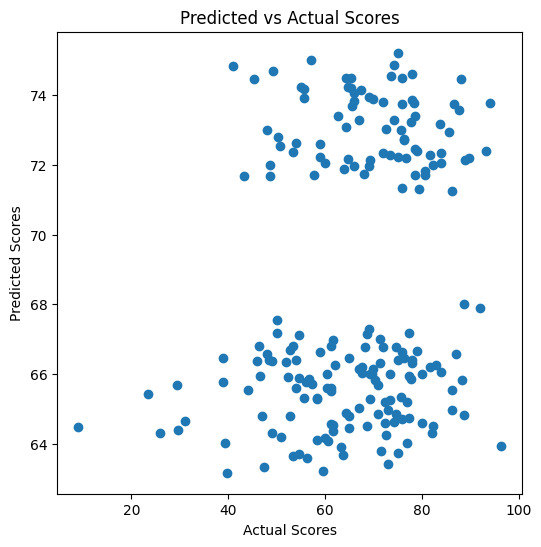

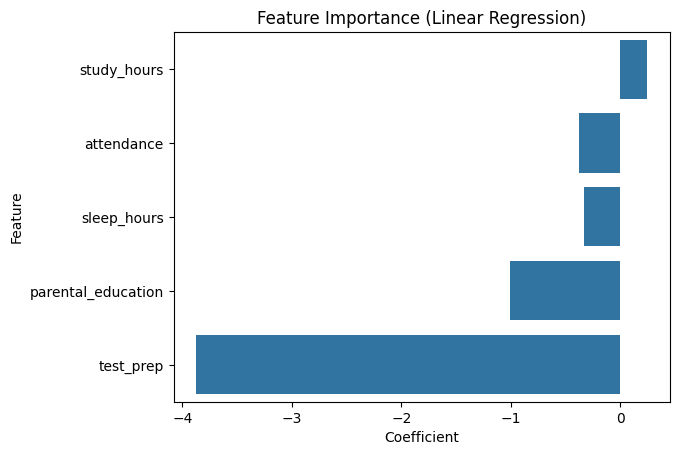

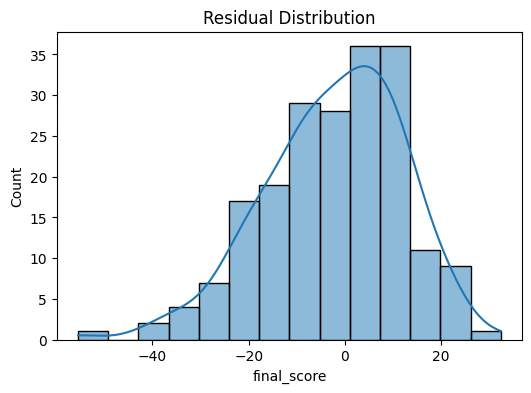

In [14]:

X_reduced = df[["study_hours", "attendance", "parental_education"]]
X_scaled_reduced = scaler.fit_transform(X_reduced)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled_reduced, y, test_size=0.2, random_state=42)

model_reduced = LinearRegression()
model_reduced.fit(X_train_r, y_train_r)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Predicted vs Actual Scores")
plt.show()
sns.barplot(x="Coefficient", y="Feature", data=coefficients)
plt.title("Feature Importance (Linear Regression)")
plt.show()
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()



In [15]:
# Name: S.ASWIN
# Roll No: 24BAD014
# Lab: Polynomial Regression - Auto MPG Dataset




         MSE      RMSE        R2
2  13.760855  3.709563  0.744062
3  13.813374  3.716635  0.743086
4  14.118024  3.757396  0.737419
Ridge R2: 0.7393719439438626


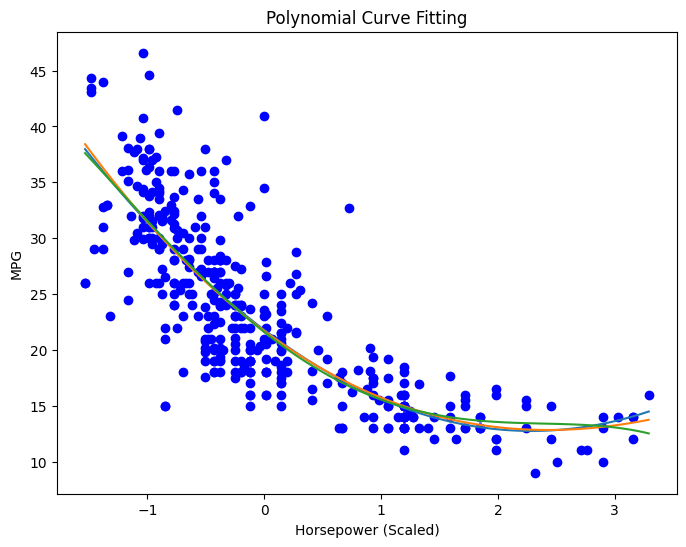

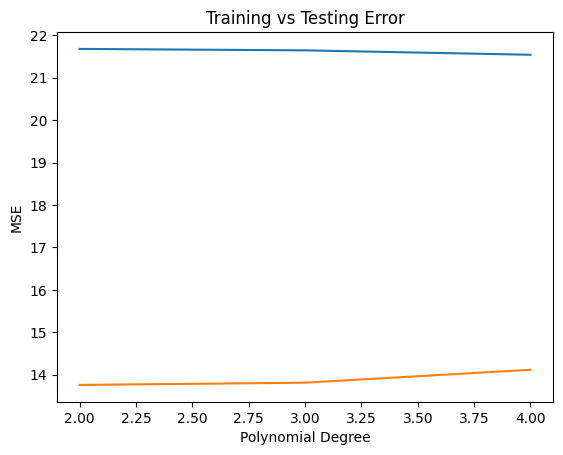

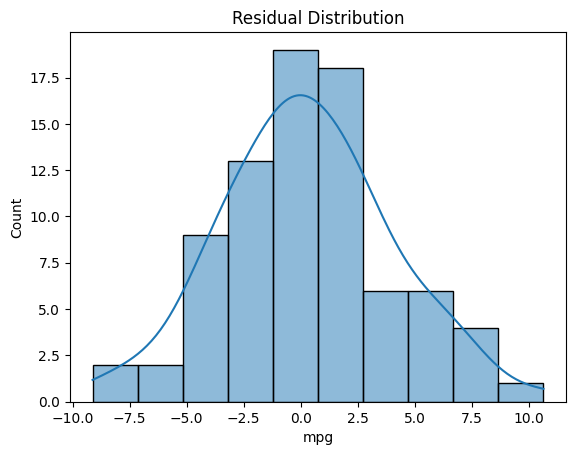

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("auto-mpg.csv")
df.replace('?', np.nan, inplace=True)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

X = df[['horsepower']]
y = df['mpg']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

degrees = [2, 3, 4]
results = {}
train_errors = []
test_errors = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[d] = {"MSE": mse, "RMSE": rmse, "R2": r2}

    train_pred = model.predict(X_train_poly)
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mse)

results_df = pd.DataFrame(results).T
print(results_df)

poly4 = PolynomialFeatures(degree=4)
X_train_poly4 = poly4.fit_transform(X_train)
X_test_poly4 = poly4.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly4, y_train)
ridge_pred = ridge.predict(X_test_poly4)
print("Ridge R2:", r2_score(y_test, ridge_pred))

plt.figure(figsize=(8,6))
plt.scatter(X_scaled, y, color='blue')
x_range = np.linspace(X_scaled.min(), X_scaled.max(), 100).reshape(-1,1)

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    model = LinearRegression()
    model.fit(poly.fit_transform(X_scaled), y)
    y_curve = model.predict(poly.transform(x_range))
    plt.plot(x_range, y_curve)

plt.xlabel("Horsepower (Scaled)")
plt.ylabel("MPG")
plt.title("Polynomial Curve Fitting")
plt.show()

plt.figure()
plt.plot(degrees, train_errors)
plt.plot(degrees, test_errors)
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training vs Testing Error")
plt.show()

poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)

model3 = LinearRegression()
model3.fit(X_train_poly3, y_train)

residuals = y_test - model3.predict(X_test_poly3)

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()
